# **CAM tutorial with pretrained YOLO model**

Hello, friends!
In this tutorial, you will learn how to use Class Activation Maps (CAM) to analyze the YOLO NAS S model. We'll explore how to interpret the model's decisions, helping you understand which features the model extracts and which regions of the image it focuses on.

### **Why Is This Important?**
Explainable AI (XAI) enables the development of more transparent and reliable models while ensuring confidence when applying them in high-stakes business scenarios. My goal is to create several practical guides for using XAI in real-world workflows.

### **n This Tutorial, You Will Learn:**
- How to load and test YOLO NAS S using the `super-gradients` library.
- How to create Class Activation Maps (CAM) from scratch, without relying on prebuilt libraries.
- How to analyze the model's performance by examining feature extraction in the `backbone` and their processing in the `heads`.
= How to apply CAM to improve model performance in real-world tasks.


### **We Will Use:**
**Yolo-framework:** `super-gradients` [](https://github.com/Deci-AI/super-gradients) \
**XAI-framework for CAM:** none — from scratch \
**Github:** https://github.com/SadSabrina/open-xai-materials

### **Outline:**
- Preparing data and loading the YOLO NAS S model.
- Extracting Class Activation Maps (CAM) from scratch.
- Analyzing the model's performance: feature extraction in the `backbone` and processing in the `head`.
- Conclusions and potential real-world applications.










In [ ]:
!pip install -U git+https://github.com/Deci-AI/super-gradients@e0ccacf8868ffa1296fa4f8407c03d2bc227312c -q

In [ ]:
# Some settings in the library, following https://github.com/Deci-AI/super-gradients/issues/2057

file_path = "/usr/local/lib/python3.11/dist-packages/super_gradients/training/pretrained_models.py"

with open(file_path, "r") as file:
    content = file.read()

content = content.replace("sghub.deci.ai", "sg-hub-nv.s3.amazonaws.com")

with open(file_path, "w") as file:
    file.write(content)

print(f"Modified {file_path}")



file_path = "/usr/local/lib/python3.11/dist-packages/super_gradients/training/utils/checkpoint_utils.py"

with open(file_path, "r") as file:
    content = file.read()

content = content.replace("sghub.deci.ai", "sg-hub-nv.s3.amazonaws.com")

with open(file_path, "w") as file:
    file.write(content)

print(f"Modified {file_path}")


# **1. Object Detection**

To obtain basic predictions and their heatmaps, we will use:
1. The pretrained YOLO NAS S model on the [COCO](https://cocodataset.org/#home) dataset;
2. A small test dataset;

First, let's load everything and gather the results.

In [ ]:
from super_gradients.training import models
from super_gradients.common.object_names import Models
import numpy as np
import requests
import matplotlib.pyplot as plt
from torch.nn import functional as F
from PIL import Image
import cv2
import torch
import requests
import ast
import os
from torchvision import transforms

We will use a model trained on the COCO dataset. The model can detect up to 80 object categories, such as people, cars, animals, etc.


In [ ]:
model = models.get(Models.YOLO_NAS_S, pretrained_weights="coco")
model.eval();

In [ ]:
!wget https://github.com/SadSabrina/open-xai-materials/raw/main/data/coco_test.zip

In [ ]:
!unzip '/content/coco_test.zip'

In [ ]:
image_dir = "/content/yolo_nas_cam_tutorial/coco_test/"
files = os.listdir(image_dir)

print(f"Images count {len(files)}")

Now, let's select one image from the dataset, convert it to the required format, and visualize it.

It is important to note that, according to the `super-gradients` library documentation, the input to `model.predict()` should be an unnormalized image. Therefore, we only need to provide unnormalized images with a resolution of `640×640`.

In [ ]:
img = np.array(Image.open(image_dir+files[5]))
img = cv2.resize(img, (640, 640))

transform = transforms.ToTensor() # if you want to have tensor
tensor = transform(img).unsqueeze(0)

fig = plt.figure(figsize=(7, 7))
plt.imshow(img)
plt.axis('off');

# **CAM: Theory**

As an auxiliary tool for evaluating the model's data processing, we will use Class Activation Maps (CAM). Class Activation Maps (CAM) are a tool that allows us to visualize which regions of an image are most important for the model when making a decision.

The construction of CAM is based on the following formula:

$$CAM_k = w^c_kA^k$$

where:
- $A^k$ is the activation map for the $k$-th class from the last convolutional layer (which performs classification);
- $w^c_k$ are the weights corresponding to the $k$-th class, taken from the output layer of the classifier;

Usually, CAM is constructed from the last layer of the CNN, just before the Global Average Pooling layer. However, since we have a different architecture, we will choose the layer differently.





# **Layer Selection**

The architecture of YOLO NAS (You Only Look Once) models consists of the `backbone`, `head`, and `neck` parts.

1. The task of the `backbone` is to extract features and characteristics from the image.

2. The task of the `neck` is to pass the features extracted by the backbone (the main part of the network that extracts features from the image) to the head.

3. The `head` performs the main task of object classification. Here, decisions are made about which object is present in the image (classification), as well as the calculation of the coordinates and sizes of bounding boxes (localization).

To view the full network architecture, simply run the command:
`model`. To access any specific part, specify its name via `.`:

- `model.backbone`
- `model.neck`
- `model.heads`



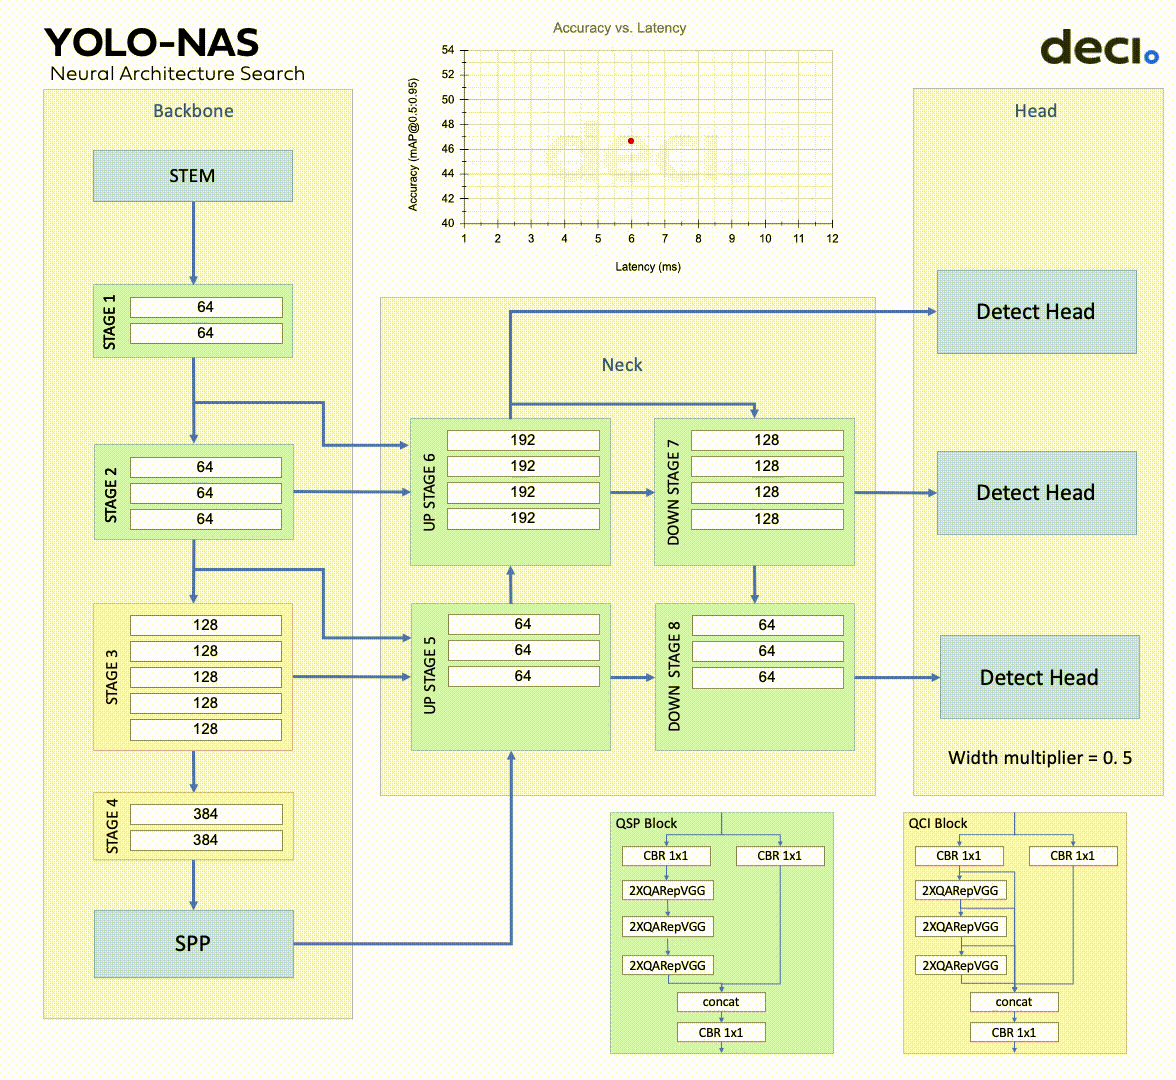

In the process of building the maps, we will look at:
- The convolution maps the model gets as output from various stages of the `backbone` to examine the extracted features.
- How the features contribute to the prediction in the `heads`. This is where we will generate Class Activation Maps (CAM).

**Note 1:**

🐻 CAMs are specifically built on the heads, as they allow us to extract weights that are added to the prediction and are responsible for the specific class. For the `backbone`, we will simply visualize the activations.

**Note 2:**

🐻 Each head has a block `cls_convs` — responsible for classification convolutions, and `cls_pred` — responsible for the prediction. We will extract the convolutions and class weights from these blocks.


In [ ]:
# model.backbone

In [ ]:
model.heads

We will also extract the indices of the true classes for the entire test dataset and save them. They will be useful later.

**Class indices:**

- bear — 22
- bird — 15
- cat — 16
- cow — 20
- giraffe — 24
- horse — 18
- sheep — 19


In [ ]:
all_classes = requests.get('https://github.com/SadSabrina/open-xai-materials/raw/main/data/ms_coco_classnames.txt').text

all_classes = all_classes.replace("u'", "'")
all_classes = ast.literal_eval(all_classes)

print(all_classes)

# **Backbone Analysis**

To extract the maps, we will write a `Hook`.

A `Hook` is a PyTorch method that allows you to "hook into" network layers to extract information (such as output activations or gradients).
The main capabilities of a Hook are:

- Intercepting layer outputs during the forward pass (forward hook).
- The ability to modify or analyze gradients during the backward pass (backward hook).


In [ ]:
# Simple Hook Class

class Hook():
    def __init__(self, m):
        self.hook = m.register_forward_hook(self.hook_func)  # Hook into the forward pass of the layer m passed during initialization

    def hook_func(self, module, input, output):
        # self.features = ((output.cpu()).data).numpy()
        self.features = output.detach().cpu().numpy()  # Get the output of the layer and convert it to a numpy array

    def remove(self):
        self.hook.remove()

We will list the parts from which we will intercept the maps. According to the task, we will collect features from each `stage` of YOLO. For each `stage`, we will intercept the result of the last convolution.


In [ ]:
stage1_layer = model.backbone.stage1.blocks._modules['bottlenecks']._modules['1'].cv2._modules['branch_1x1']
stage2_layer = model.backbone.stage2.blocks._modules['bottlenecks']._modules['1'].cv2._modules['branch_1x1']
stage3_layer = model.backbone.stage3.blocks._modules['bottlenecks']._modules['1'].cv2._modules['branch_1x1']
stage4_layer = model.backbone.stage4.blocks._modules['bottlenecks']._modules['1'].cv2._modules['branch_1x1']

for layer in [stage1_layer, stage2_layer, stage3_layer, stage4_layer]:
  print(layer)

In [ ]:
model.backbone.stage4.blocks._modules['bottlenecks']._modules['1'].cv2._modules['branch_1x1']

To obtain the maps, it is enough to pass the image through the model

In [ ]:
act_maps_stage1 = Hook(stage1_layer)
act_maps_stage2 = Hook(stage2_layer)
act_maps_stage3 = Hook(stage3_layer)
act_maps_stage4 = Hook(stage4_layer)

result = model.predict(img, fuse_model=False, conf=0.8)

act_maps_stage1.remove()
act_maps_stage2.remove()
act_maps_stage3.remove()
act_maps_stage4.remove()

In [ ]:
result.show()

In [ ]:
predicted_idx = result.prediction.labels

print(f'Model prediction: {[result.class_names[i] for i in predicted_idx]}')

The model has successfully completed the task! Now let's visualize the extracted convolutions.

In [ ]:
fig_original_stages, ax_original_stages = plt.subplots(2, 4, figsize=(16, 10))

# Mean activations
ax_original_stages[0, 0].imshow(np.mean(act_maps_stage1.features[0], axis=0))
ax_original_stages[0, 0].set_title('stage 1 mean conv')

ax_original_stages[0, 1].imshow(np.mean(act_maps_stage2.features[0], axis=0))
ax_original_stages[0, 1].set_title('stage 2 mean conv')

ax_original_stages[0, 2].imshow(np.mean(act_maps_stage3.features[0], axis=0))
ax_original_stages[0, 2].set_title('stage 3 mean conv')

ax_original_stages[0, 3].imshow(np.mean(act_maps_stage4.features[0], axis=0))
ax_original_stages[0, 3].set_title('stage 4 mean conv')

# Median activations
ax_original_stages[1, 0].imshow(np.median(act_maps_stage1.features[0], axis=0))
ax_original_stages[1, 0].set_title('stage 1 median conv')

ax_original_stages[1, 1].imshow(np.median(act_maps_stage2.features[0], axis=0))
ax_original_stages[1, 1].set_title('stage 2 median conv')

ax_original_stages[1, 2].imshow(np.median(act_maps_stage3.features[0], axis=0))
ax_original_stages[1, 2].set_title('stage 3 median conv')

ax_original_stages[1, 3].imshow(np.median(act_maps_stage4.features[0], axis=0))
ax_original_stages[1, 3].set_title('stage 4 median conv');

**Notes:**
- The median and mean activation values differ in strength, indicating that the convolution filters do not evenly focus on different features at this stage.
- The further along the `stage` you go, the larger parts of the image are analyzed.


# **Analysis of the heads**

Now, let's build the CAM for the class of interest (22). We will extract the last convolutional layer before classification from each of the three heads. Each head outputs a convolution of a different size, which is noted in the code after `#`.

In [ ]:
# Layers the convolutions are taken from
final_layer_head3 = model.heads.head3.cls_convs._modules['0']._modules['seq'][0] #256, 20, 20
final_layer_head2 = model.heads.head2.cls_convs._modules['0']._modules['seq'][0] # 128 40, 40
final_layer_head1 = model.heads.head1.cls_convs._modules['0']._modules['seq'][0] # 128 40, 40

# Layers the weights are taken from
weights_interested_head3 = model.heads.head3.cls_pred.weight[23, :].cpu().data.numpy()
weights_interested_head2 = model.heads.head2.cls_pred.weight[23, :].cpu().data.numpy()
weights_interested_head1 = model.heads.head1.cls_pred.weight[23, :].cpu().data.numpy()

In [ ]:
act_maps_head3 = Hook(final_layer_head3)
act_maps_head2 = Hook(final_layer_head2)
act_maps_head1 = Hook(final_layer_head1)

results = model.predict(img, fuse_model=False)

act_maps_head3.remove()
act_maps_head2.remove()
act_maps_head1.remove()

In [ ]:
act_maps_head3.features[0].shape, act_maps_head2.features[0].shape, act_maps_head1.features[0].shape

In [ ]:
cam_head3 = weights_interested_head3.reshape(256).dot(act_maps_head3.features[0].reshape((256, 20*20)))
cam_head2 = weights_interested_head2.reshape(128).dot(act_maps_head2.features[0].reshape((128, 40*40)))
cam_head1 = weights_interested_head1.reshape(64).dot(act_maps_head1.features[0].reshape((64, 80*80)))

cam_head3 = cam_head3.reshape((20,20))
cam_head2 = cam_head2.reshape((40,40))
cam_head1 = cam_head1.reshape((80,80))

cam1_tensor = torch.from_numpy(cam_head1).float().unsqueeze(0).unsqueeze(0)  # convert back to a tensor
interpol_head1 = F.interpolate(cam1_tensor, (640, 640), mode="bilinear").squeeze(0).squeeze(0)
cam2_tensor = torch.from_numpy(cam_head2).float().unsqueeze(0).unsqueeze(0)
interpol_head2 = F.interpolate(cam2_tensor, (640, 640), mode="bilinear").squeeze(0).squeeze(0)
cam3_tensor = torch.from_numpy(cam_head3).float().unsqueeze(0).unsqueeze(0)
interpol_head3 = F.interpolate(cam3_tensor, (640, 640), mode="bilinear").squeeze(0).squeeze(0)

In [ ]:
fig_original_CAM, ax_original_CAM = plt.subplots(3, 3, figsize=(16, 10))

# Mean activations
ax_original_CAM[0, 0].imshow(np.mean(act_maps_head1.features[0], axis=0))
ax_original_CAM[0, 0].set_title('Head 1 mean conv')

ax_original_CAM[0, 1].imshow(np.mean(act_maps_head2.features[0], axis=0))
ax_original_CAM[0, 1].set_title('Head 2 mean conv')

ax_original_CAM[0, 2].imshow(np.mean(act_maps_head3.features[0], axis=0))
ax_original_CAM[0, 2].set_title('Head 3 mean conv')


# Median activations
ax_original_CAM[1, 0].imshow(np.mean(act_maps_head1.features[0], axis=0))
ax_original_CAM[1, 0].set_title('Head 1 median conv')

ax_original_CAM[1, 1].imshow(np.mean(act_maps_head2.features[0], axis=0))
ax_original_CAM[1, 1].set_title('Head 2 median conv')

ax_original_CAM[1, 2].imshow(np.mean(act_maps_head3.features[0], axis=0))
ax_original_CAM[1, 2].set_title('Head 3 median conv')

# CAMs

ax_original_CAM[2, 0].imshow(cam_head1)
ax_original_CAM[2, 0].set_title('Head 1 CAM')

ax_original_CAM[2, 1].imshow(cam_head2)
ax_original_CAM[2, 1].set_title('Head 2 CAM')

ax_original_CAM[2, 2].imshow(cam_head3)
ax_original_CAM[2, 2].set_title('Head 3 CAM');

plt.axis('off')

**Notes:**
- Each successive head highlights "larger" features compared to the previous one (similar to the `stages`).
- The mean and median values of the convolutions are close, which suggests that the features extracted by the filters are stabilizing.


In [ ]:
fig_original_interpol, ax_original_interpol = plt.subplots(1, 3, figsize=(18, 4))

ax_original_interpol[0].imshow(interpol_head1, alpha=0.5, cmap='jet');
ax_original_interpol[0].set_title('First head')

ax_original_interpol[1].imshow(interpol_head2, alpha=0.5, cmap='jet');
ax_original_interpol[1].set_title('Second head')

ax_original_interpol[2].imshow(interpol_head3, alpha=0.5, cmap='jet');
ax_original_interpol[2].set_title('Third head')
plt.axis('off');

# **What can we do with activation maps? Model Robustness Analysis.**

Extracting activation maps is not only an exciting theoretical process for analyzing the propagation of features in an image. Based on these maps, we can analyze how various interventions (such as adding noise) affect the extracted features in different parts of the model. In turn, this allows us to draw conclusions about the model's robustness and form hypotheses for improving the model.

As an example, let's see how random noise affects the activations.

In [ ]:
torch.manual_seed(42)

def add_gaussian_noise(image_tensor, mean=0.0, std=0.1):
    """Adds Gaussian noise to the image."""
    noise = torch.normal(mean=mean, std=std, size=image_tensor.shape)
    noisy_image = image_tensor + noise

    noisy_tensor = torch.clamp(noisy_image, 0.0, 1.0)
    to_pil = transforms.ToPILImage()
    noisy_image = to_pil(noisy_tensor[0])

    return noisy_tensor, noisy_image

noisy_tensor, noisy_image = add_gaussian_noise(tensor)

fig = plt.figure(figsize=(7, 7))
plt.imshow(noisy_image)
plt.title('Image with gaussian noise')

plt.axis('off')

Let's repeat the entire process of extracting the activation maps again.


In [ ]:
# Stages
act_maps_stage1_noisy = Hook(stage1_layer)
act_maps_stage2_noisy = Hook(stage2_layer)
act_maps_stage3_noisy = Hook(stage3_layer)
act_maps_stage4_noisy = Hook(stage4_layer)

# Heads
act_maps_head3_noisy = Hook(final_layer_head3)
act_maps_head2_noisy = Hook(final_layer_head2)
act_maps_head1_noisy = Hook(final_layer_head1)

# Prediction
result = model.predict(noisy_image, fuse_model=False, conf=0.5)

# remove
act_maps_stage1_noisy.remove()
act_maps_stage2_noisy.remove()
act_maps_stage3_noisy.remove()
act_maps_stage4_noisy.remove()

act_maps_head3_noisy.remove()
act_maps_head2_noisy.remove()
act_maps_head1_noisy.remove()

In [ ]:
result.show()

In [ ]:
predicted_idx = result.prediction.labels

print(f'Model prediction: {[result.class_names[i] for i in predicted_idx]}')

The model's prediction changed significantly. Additionally, we had to lower the confidence threshold (`conf`) from 0.8 to 0.5, indicating a change in the model's internal processing of the image.

For a detailed analysis, let's examine the activation maps.

In [ ]:
fig_noisy_stages, ax_noisy_stages = plt.subplots(2, 4, figsize=(16, 10))

# Mean activations
ax_noisy_stages[0, 0].imshow(np.mean(act_maps_stage1_noisy.features[0], axis=0))
ax_noisy_stages[0, 0].set_title('stage 1 mean conv')

ax_noisy_stages[0, 1].imshow(np.mean(act_maps_stage2_noisy.features[0], axis=0))
ax_noisy_stages[0, 1].set_title('stage 2 mean conv')

ax_noisy_stages[0, 2].imshow(np.mean(act_maps_stage3_noisy.features[0], axis=0))
ax_noisy_stages[0, 2].set_title('stage 3 mean conv')

ax_noisy_stages[0, 3].imshow(np.mean(act_maps_stage4_noisy.features[0], axis=0))
ax_noisy_stages[0, 3].set_title('stage 4 mean conv')

# Median activations
ax_noisy_stages[1, 0].imshow(np.median(act_maps_stage1_noisy.features[0], axis=0))
ax_noisy_stages[1, 0].set_title('stage 1 median conv')

ax_noisy_stages[1, 1].imshow(np.median(act_maps_stage2_noisy.features[0], axis=0))
ax_noisy_stages[1, 1].set_title('stage 2 median conv')

ax_noisy_stages[1, 2].imshow(np.median(act_maps_stage3_noisy.features[0], axis=0))
ax_noisy_stages[1, 2].set_title('stage 3 median conv')

ax_noisy_stages[1, 3].imshow(np.median(act_maps_stage4_noisy.features[0], axis=0))
ax_noisy_stages[1, 3].set_title('stage 4 median conv');

In [ ]:
fig_original_stages

**Notes:**
- For the noisy image, `stage2` and `stage3` highlight the bear's contours more clearly.
- For both the original and noisy images, `stage4` focuses its "attention" on different areas, as seen in the median convolution values.

However, to focus not only on the visual information, let's also look at the distances between:
- the original and noisy images
- the original and noisy convolutions


In [ ]:
images_difference = torch.mean(np.abs(tensor - noisy_tensor))

stages_difference = np.array([np.mean(np.abs(act_maps_stage1_noisy.features[0] - act_maps_stage1.features[0])),
                              np.mean(np.abs(act_maps_stage2_noisy.features[0] - act_maps_stage2.features[0])),
                              np.mean(np.abs(act_maps_stage3_noisy.features[0] - act_maps_stage3.features[0])),
                              np.mean(np.abs(act_maps_stage4_noisy.features[0] - act_maps_stage4.features[0]))])

print(f'tensor images distance:{images_difference} \n stages distances:{stages_difference}')

The strongest distance occurs for stage 1, which is not visually noticeable.  
Let's analyze the CAM (Class Activation Maps).

In [ ]:
cam_head3_noisy = weights_interested_head3.reshape(256).dot(act_maps_head3_noisy.features[0].reshape((256, 20*20)))
cam_head2_noisy = weights_interested_head2.reshape(128).dot(act_maps_head2_noisy.features[0].reshape((128, 40*40)))
cam_head1_noisy = weights_interested_head1.reshape(64).dot(act_maps_head1_noisy.features[0].reshape((64, 80*80)))

cam_head3_noisy = cam_head3_noisy.reshape((20,20))
cam_head2_noisy = cam_head2_noisy.reshape((40,40))
cam_head1_noisy = cam_head1_noisy.reshape((80,80))

cam1_tensor_noisy = torch.from_numpy(cam_head1_noisy).float().unsqueeze(0).unsqueeze(0)  # convert back to a tensor
interpol_head1 = F.interpolate(cam1_tensor_noisy, (640, 640), mode="bilinear").squeeze(0).squeeze(0)

cam2_tensor_noisy = torch.from_numpy(cam_head2_noisy).float().unsqueeze(0).unsqueeze(0)  # convert back to a tensor
interpol_head2 = F.interpolate(cam2_tensor_noisy, (640, 640), mode="bilinear").squeeze(0).squeeze(0)

cam3_tensor_noisy = torch.from_numpy(cam_head3_noisy).float().unsqueeze(0).unsqueeze(0)  # convert back to a tensor
interpol_head3 = F.interpolate(cam3_tensor_noisy, (640, 640), mode="bilinear").squeeze(0).squeeze(0)

In [ ]:
fig_noisy_heads, ax_noisy_heads = plt.subplots(3, 3, figsize=(16, 10))

# Mean activations
ax_noisy_heads[0, 0].imshow(np.mean(act_maps_head1_noisy.features[0], axis=0))
ax_noisy_heads[0, 0].set_title('Head 1 mean conv')

ax_noisy_heads[0, 1].imshow(np.mean(act_maps_head2_noisy.features[0], axis=0))
ax_noisy_heads[0, 1].set_title('Head 2 mean conv')

ax_noisy_heads[0, 2].imshow(np.mean(act_maps_head3_noisy.features[0], axis=0))
ax_noisy_heads[0, 2].set_title('Head 3 mean conv')


# Median activations
ax_noisy_heads[1, 0].imshow(np.mean(act_maps_head1_noisy.features[0], axis=0))
ax_noisy_heads[1, 0].set_title('Head 1 median conv')

ax_noisy_heads[1, 1].imshow(np.mean(act_maps_head2_noisy.features[0], axis=0))
ax_noisy_heads[1, 1].set_title('Head 2 median conv')

ax_noisy_heads[1, 2].imshow(np.mean(act_maps_head3_noisy.features[0], axis=0))
ax_noisy_heads[1, 2].set_title('Head 3 median conv')

# CAMs

ax_noisy_heads[2, 0].imshow(cam_head1_noisy)
ax_noisy_heads[2, 0].set_title('Head 1 CAM')

ax_noisy_heads[2, 1].imshow(cam_head2_noisy)
ax_noisy_heads[2, 1].set_title('Head 2 CAM')

ax_noisy_heads[2, 2].imshow(cam_head3_noisy)
ax_noisy_heads[2, 2].set_title('Head 3 CAM');

In [ ]:
fig_original_CAM

**Notes:**
- The localizations from heads 3, 2, and 1, constructed from the CAM, are different.

Now, let's look at the distances.

In [ ]:
heads_difference = np.array([np.mean(np.abs(act_maps_head1_noisy.features[0] - act_maps_head1.features[0])),
                              np.mean(np.abs(act_maps_head2_noisy.features[0] - act_maps_head2.features[0])),
                              np.mean(np.abs(act_maps_head3_noisy.features[0] - act_maps_head3.features[0]))])

print(f'tensor images distance:{images_difference} \n heads distances:{heads_difference}')

The distances are also small, but the largest difference is found in head 1. However, the order of difference (in the hundredths) is stronger than in the `stages`.

In [ ]:
[images_difference]*4 / stages_difference, [images_difference]*3 / heads_difference

In [ ]:
fig_noisy_interpol, ax_noisy_interpol = plt.subplots(1, 3, figsize=(18, 4))

ax_noisy_interpol[0].imshow(interpol_head1, alpha=0.5, cmap='jet');
ax_noisy_interpol[0].set_title('First head')

ax_noisy_interpol[1].imshow(interpol_head2, alpha=0.5, cmap='jet');
ax_noisy_interpol[1].set_title('Second head')

ax_noisy_interpol[2].imshow(interpol_head3, alpha=0.5, cmap='jet');
ax_noisy_interpol[2].set_title('Third head')

plt.axis('off');

In [ ]:
fig_original_interpol

The interpolation maps confirm and reinforce the observations — each of the three heads localizes on different areas.


# **Conclusions**

During the study, we found that even a small amount of noise in the image, such as that caused by transmission interference, can significantly affect the model's prediction accuracy. This highlights the importance of data preprocessing and model robustness to noise.

Thank you for your attention! 🤗 I hope the material presented will be useful for your projects. You can experiment with other images to uncover even more patterns.

Join the [Telegram channel (rus)](https://t.me/jdata_blog) to see new tutorials! I also invite you to take my [course](https://open-xai-platform.web.app) on explainable AI, and of course, I would be happy to connect with you on [LinkedIn](https://www.linkedin.com/in/sabrina-sadiekh-35181a286/).

Wishing you successful projects!  
Your Data Author!